Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

In [24]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [37]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

X = df[['Valor_Condominio','Metragem','N_Quartos','N_banheiros','N_Suites','N_Vagas']]
y = df['Valor_Aluguel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Primeira etapa de pré processamento dos dados.

A) Verificar os tipos de dados.


B) Verificar os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando.

In [29]:
#Tipos de dados
df.dtypes

#verificação de dados faltantes
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

#Não identifiquei valores faltantes. Para não gerar tipos de viés, nenhum valor foi excluido ou substituído.

# 2 - Segunda etapa de pré processamento dos dados.

A) função describe para identificarmos outliers e verificar a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realizar a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

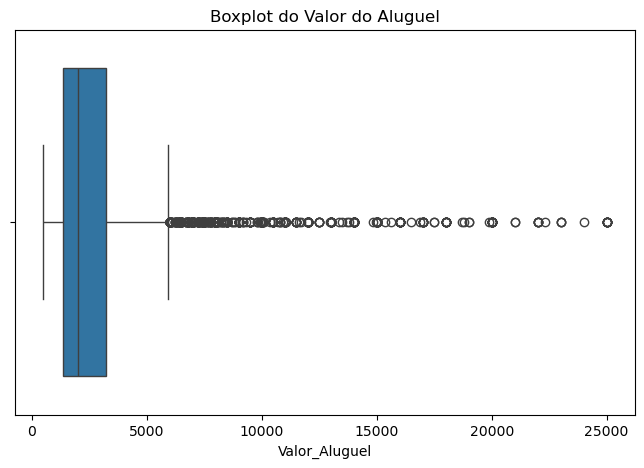

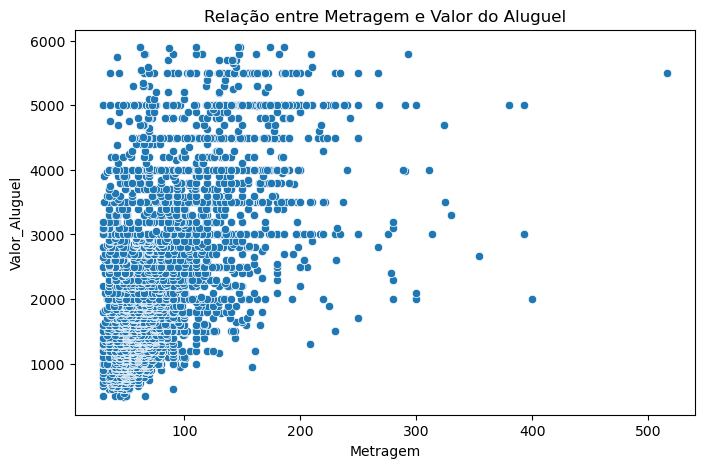

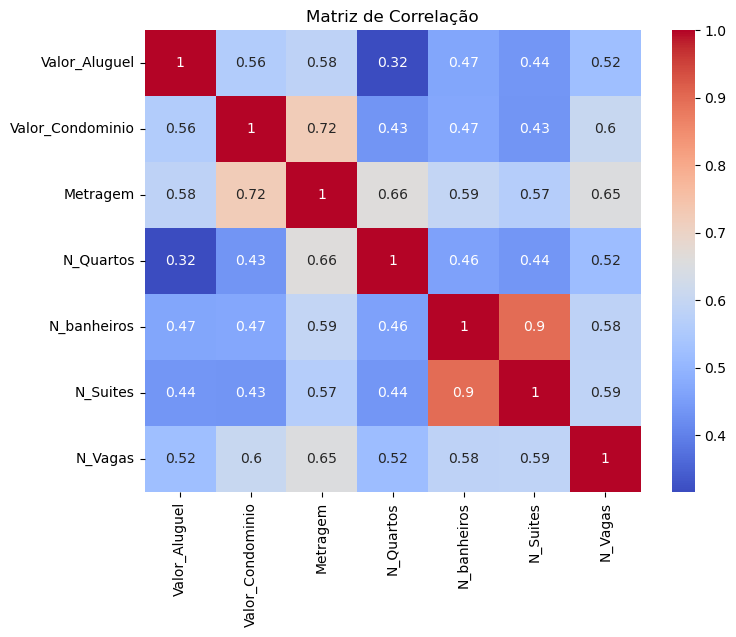

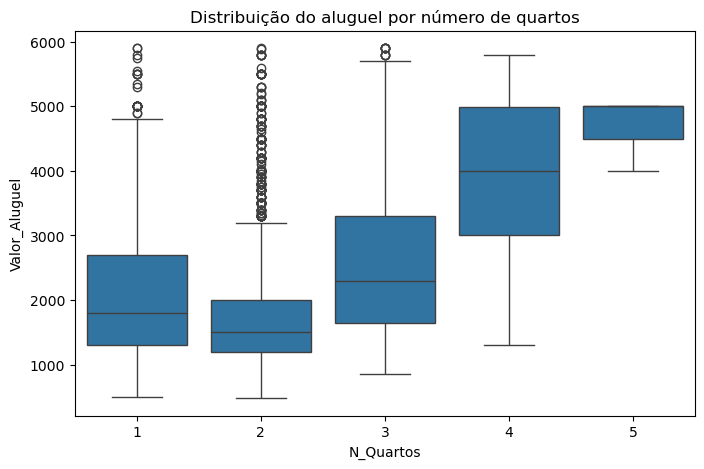

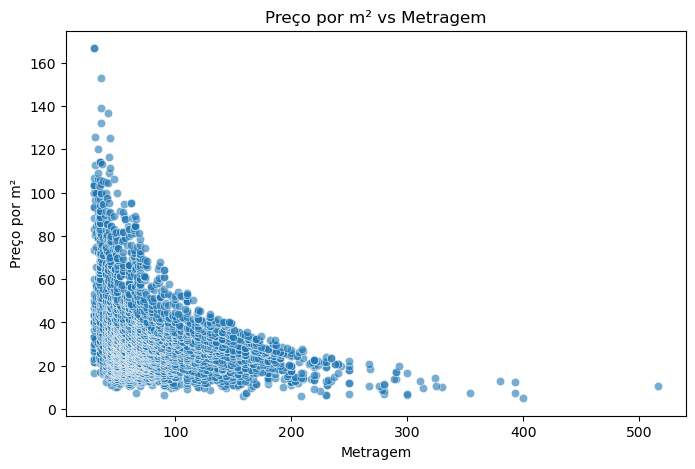

In [30]:
#A)
df.describe()

#B) Método para tratamento de outliers utilizado foi o IQR. Nesse modelo de negócio, valores extremos podem distorcer a regressão linear, além de
##serem casos raros no mercado.
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Valor_Aluguel'])
plt.title('Boxplot do Valor do Aluguel')
plt.show()

Q1 = df['Valor_Aluguel'].quantile(0.25)
Q3 = df['Valor_Aluguel'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df = df[(df['Valor_Aluguel'] >= limite_inferior) & 
        (df['Valor_Aluguel'] <= limite_superior)]

#C)Análise Bivariada 1: Metragem vs Valor do aluguel
plt.figure(figsize=(8,5))
sns.scatterplot(x='Metragem', y='Valor_Aluguel', data=df)
plt.title('Relação entre Metragem e Valor do Aluguel')
plt.show()

#C)Heatmap de correlação
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

#C)Boxplot Quartos vs Aluguel
plt.figure(figsize=(8,5))
sns.boxplot(x='N_Quartos', y='Valor_Aluguel', data=df)
plt.title('Distribuição do aluguel por número de quartos')
plt.show()

#C)Dispesão
df['Preco_m2'] = df['Valor_Aluguel'] / df['Metragem']

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Metragem',
    y='Preco_m2',
    data=df,
    alpha=0.6
)

plt.title('Preço por m² vs Metragem')
plt.xlabel('Metragem')
plt.ylabel('Preço por m²')

plt.show()

# Justificativa e insights: 

* Na metragem vs valor do aluguel, existe a tendência positiva de estarem relacionados. Quanto maior a metragem, maior o valor do aluguel. Essa pode ser uma variável importante mais para frente.

* A quantidade de cômodos (número de quartos, banheiros, sala, cozinha, vagas...) também são variáveis significativas e que impactam o valor dos alugueis. Podemos verificar a representatividade de cada através do mapa de calor.

* Mesmo que imóveis com mais quartos tem a tendência de custarem mais, podemos notar uma variedade aqui. Principalmente nos imóveis de apenas 1 quarto, o que não explica o preço. Essa variedade pode indicar outros dados que não temos nesse momento, como localização por exemplo.

* No gráfico de dispersão, podemos ver uma tendência crescente. Mostrando que imóveis maiores, tendem a ser mais caros. Porém ao mesmo tempo, também não perfeitamente linear. O que pode significar uma demanda para apartamentos mais conteporâneos e mais compactos.

# 3º etapa de pré processamento dos dados.

A) Começando pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Segue o gráfico ou a tabela e indicação das variáveis mais "fortes" na correlação do modelo.

B) separe treino e teste. Lembre-se que primeiro separamos as variaveis dependentes X e depois Y.



                  Valor_Aluguel  Valor_Condominio  Metragem  N_Quartos  \
Valor_Aluguel          1.000000          0.559615  0.583438   0.315207   
Valor_Condominio       0.559615          1.000000  0.724093   0.434325   
Metragem               0.583438          0.724093  1.000000   0.661215   
N_Quartos              0.315207          0.434325  0.661215   1.000000   
N_banheiros            0.467663          0.469310  0.594334   0.458910   
N_Suites               0.437841          0.434219  0.565509   0.435620   
N_Vagas                0.521301          0.604575  0.653936   0.516464   
Preco_m2               0.515481         -0.015179 -0.267839  -0.394048   

                  N_banheiros  N_Suites   N_Vagas  Preco_m2  
Valor_Aluguel        0.467663  0.437841  0.521301  0.515481  
Valor_Condominio     0.469310  0.434219  0.604575 -0.015179  
Metragem             0.594334  0.565509  0.653936 -0.267839  
N_Quartos            0.458910  0.435620  0.516464 -0.394048  
N_banheiros          1.

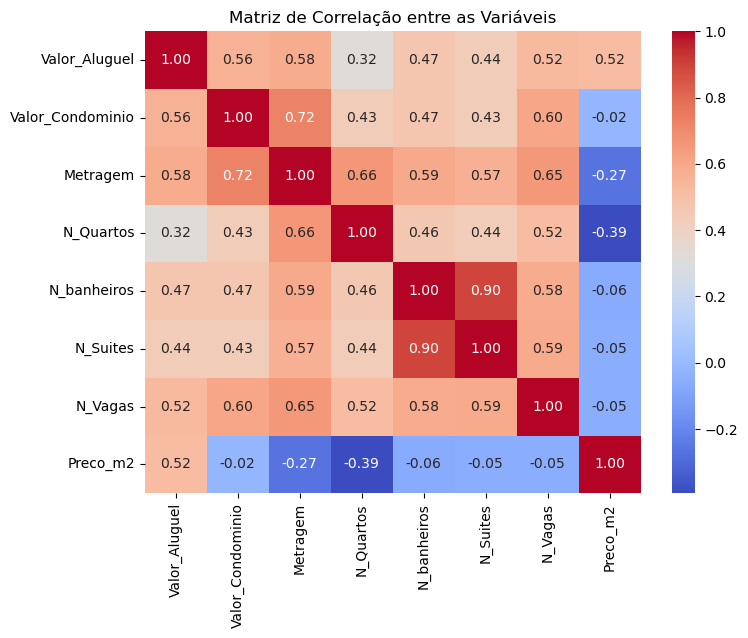

X treino: (4517, 7)
X teste: (1937, 7)
y treino: (4517,)
y teste: (1937,)


In [31]:
# matriz de correlação (Pearson)
correlacao = df.corr()

# Exibir tabela
print(correlacao)

#heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Matriz de Correlação entre as Variáveis')

plt.show()

#B) # Variável dependente (target)
y = df['Valor_Aluguel']

# Variáveis independentes (features)
X = df.drop('Valor_Aluguel', axis=1)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("X treino:", X_treino.shape)
print("X teste:", X_teste.shape)

print("y treino:", y_treino.shape)
print("y teste:", y_teste.shape)

In [ ]:
# Seu código aqui

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.

Intercepto: -96.998960399324
Coeficiente: 34.47397089324875
Preço = -97.00 + 34.47 * Metragem
R² nos dados de treinamento: 0.5213632318517781


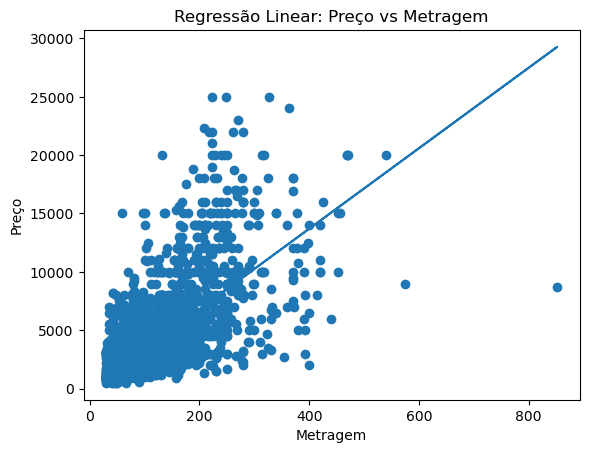

In [42]:
#A) #Selecionando apenas a variável metragem
X_train_metragem = X_train[['Metragem']]

# Criando o modelo
modelo = LinearRegression()

# Treinando o modelo
modelo.fit(X_train_metragem, y_train)

#B)Intercepto, coef e equação da reta
intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]

print("Intercepto:", intercepto)
print("Coeficiente:", coeficiente)

print(f"Preço = {intercepto:.2f} + {coeficiente:.2f} * Metragem")

#C)R QUADRADO
r2_treino = modelo.score(X_train_metragem, y_train)

print("R² nos dados de treinamento:", r2_treino)

#D)Reta de regressão
plt.scatter(X_train_metragem, y_train)
plt.plot(X_train_metragem, modelo.predict(X_train_metragem))

plt.xlabel("Metragem")
plt.ylabel("Preço")
plt.title("Regressão Linear: Preço vs Metragem")

plt.show()

# Insights

* sobre o R²: 52% sugere que a metragem é uma variável importante, mas que outros fatores também influenciam o preço, como localização, número de quartos e vagas de garagem.

* Sobre o gráfico: Os pontos estão dispersos sobre a reta, o que mostra que a metragem do apartamento não é apenas o fator de maior relevância para o impacto no valor do aluguel. Temos diversos fatores.

#F) AVALIAÇÃO DO R no treino e no teste

O R está em 52%, o que mostra que temos outros pontos de relevância significativa que podem impactar no valor do aluguel, não somente a metragem, conforme utilizada no treinamento simples. 

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

C) Traga o valor do R quadrado e avalie o valor encontrado.

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

In [47]:
#A)
# Separando variáveis independentes (todas menos o valor do aluguel)
X = df.drop("Valor_Aluguel", axis=1)

# Variável dependente
y = df["Valor_Aluguel"]

# Separando treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X treino:", X_train.shape)
print("X teste:", X_test.shape)

#B)
modelo_multiplo = LinearRegression()

modelo_multiplo.fit(X_train, y_train)

#C)
r2_treino_multiplo = modelo_multiplo.score(X_train, y_train)

print("R² Treino (Múltipla):", r2_treino_multiplo)

#D)
r2_teste_multiplo = modelo_multiplo.score(X_test, y_test)

print("R² Teste (Múltipla):", r2_teste_multiplo)

#E)
print("R² Simples (Treino):", r2_treino)
print("R² Múltipla (Treino):", r2_treino_multiplo)
print("R² Múltipla (Teste):", r2_teste_multiplo)

X treino: (5042, 6)
X teste: (2161, 6)
R² Treino (Múltipla): 0.5956434956405704
R² Teste (Múltipla): 0.6307353793799015
R² Simples (Treino): 0.5213632318517781
R² Múltipla (Treino): 0.5956434956405704
R² Múltipla (Teste): 0.6307353793799015


# Resposta E

O modelo de regressão linear múltipla apresentou desempenho superior ao modelo de regressão simples, demonstrando que o preço do aluguel é influenciado por diversas características do imóvel além da metragem. A inclusão dessas variáveis adicionais permitiu ao modelo explicar uma parcela maior da variabilidade dos dados, resultando em um R² mais elevado.